# 📊 Evaluating Machine Learning Models — Simple Edition

**The beginner-friendly version of the full course.**

- This notebook teaches the **essential** evaluation skills: the confusion matrix,
  accuracy, precision, recall, F1, ROC/AUC, and how to pick the right metric for a
  real problem.
- Explanations are short and use plain language, with small worked examples and simple
  code.
- **Want to go deeper?** The full notebook `ML_Model_Evaluation.ipynb` covers every
  topic here in depth, and adds probability calibration, cost-sensitive decision rules,
  data leakage, time-series evaluation, cross-validation details, and interactive
  widgets.

> **The one idea behind this entire notebook:** do not ask only *which model has the
> highest score*. Ask which metric fits the problem, what each type of error costs, and
> what happens when the model is wrong.


In [1]:
# --- Setup: imports and reproducibility ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.datasets import make_classification, make_regression
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report,
                             roc_curve, roc_auc_score,
                             mean_absolute_error, mean_squared_error, r2_score)

%matplotlib inline
np.random.seed(42)   # reproducibility: the same notebook run twice gives the same output

print("Imports OK")

Imports OK


## How This Notebook Fits with the Full Course

This is the **Simple edition** — the essential evaluation curriculum in plain language:
17 short sections, about 1–2 hours, no advanced topics and no widgets. The full course,
`ML_Model_Evaluation.ipynb`, covers every topic here in depth — and adds much more.

### Recommended reading paths

| Path | What you do | Best for |
|---|---|---|
| **Beginner** | This notebook, 1 → 2 → … → 17 straight through | First contact, quick revision |
| **Hybrid** | Start here; jump to the full course via the “go deeper” cards at the end of every section | Learning while exploring |
| **Deep** | The full course, 1 → 2 → … → 29 in order | The complete treatment |

### Topics that exist only in the full course

- **Section 2** — Classification vs Regression
- **Section 12** — ROC-AUC vs Precision–Recall
- **Section 13** — Probability Calibration
- **Section 16** — Multiclass Evaluation
- **Section 18** — Data Leakage — When Your Model Cheats
- **Section 19** — Time-Series Evaluation — Never Shuffle the Clock
- **Section 25** — Common Mistakes
- **Section 26** — Beginner vs Expert Summary

If a topic here interests you, the “go deeper” card at the end of its section names the
matching section of the full course.


## Learning Objectives

After working through this notebook you should be able to:

- Read a confusion matrix and explain TP, TN, FP, FN in plain words
- Compute accuracy, precision, recall, specificity and F1 by hand **and** with
  scikit-learn
- Explain why accuracy can be misleading when classes are imbalanced
- Explain the difference between a false positive and a false negative — and which one
  is more expensive in a given business scenario
- Explain what a classification threshold is and how changing it trades precision
  against recall
- Read an ROC curve and interpret AUC
- Explain how regression models are evaluated (MAE, RMSE, R²)
- Choose a sensible metric **and** threshold for a simple real-world problem

**Before you start:** install the libraries with
`pip install numpy pandas matplotlib scikit-learn`, then run the cell below.


<a id="toc"></a>
## Table of Contents

1. [Introduction to Model Evaluation](#sec1)
2. [The Confusion Matrix](#sec2)
3. [Accuracy](#sec3)
4. [Precision](#sec4)
5. [Recall (Sensitivity)](#sec5)
6. [Specificity](#sec6)
7. [F1 Score](#sec7)
8. [The Precision–Recall Trade-off](#sec8)
9. [ROC Curve and AUC](#sec9)
10. [The Classification Report](#sec10)
11. [Imbalanced Datasets](#sec11)
12. [Cross-Validation](#sec12)
13. [Regression Metrics](#sec13)
14. [Mini Case Study: Loan Default Prediction](#sec14)
15. [Cheat Sheet](#sec15)
16. [Practice Exercises](#sec16)
17. [Final Quiz](#sec17)

---


In [2]:
# --- Setup: imports and reproducibility ---
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.datasets import make_classification, make_regression
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             confusion_matrix, classification_report,
                             roc_curve, roc_auc_score,
                             mean_absolute_error, mean_squared_error, r2_score)

%matplotlib inline
np.random.seed(42)   # reproducibility: the same notebook run twice gives the same output

print("Imports OK")

Imports OK


<a id="sec1"></a>
## 1. Introduction to Model Evaluation

### What is model evaluation?

**Model evaluation** means measuring how good a model's predictions are on data it has
**not seen before**. That last part is the whole point: a model that memorizes its
training data looks perfect in the lab and fails in the real world.

### Why evaluate at all?

- **To choose between models** — which of several candidates should we deploy?
- **To detect problems** — is the model overfitting (memorizing instead of learning)?
- **To set expectations** — how often will the model be wrong, and what does that cost?

### Training vs test data

We split the data into a **training set** (the model learns from it) and a **test set**
(we measure the model on it). **Never judge a model on data it trained on** — it has
already seen the answers.

- **Overfitting:** the model memorizes the training data (including its noise) and
  performs worse on new data. *Symptom: great training score, worse test score.*
- **Generalization:** the model performs well on **new** data. This is the actual goal.

### The three questions of evaluation

| Question | Example |
|---|---|
| **Technical:** which model has the highest score? | "Model A beats Model B by 2% accuracy." |
| **Data-science:** which metric matters for this problem? | "We care about recall here, not accuracy." |
| **Real-world:** what happens when the model is wrong? | "A missed disease costs lives; a false alarm costs money." |

Professional evaluation asks all three — and the last one usually decides the metric.

The next cell shows why we never trust training accuracy.


In [3]:
# --- Why we evaluate on NEW data: a quick demonstration ---
from sklearn.ensemble import RandomForestClassifier

X, y = make_classification(n_samples=1000, n_features=10, n_informative=5,
                           n_redundant=0, random_state=1)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1)

m = RandomForestClassifier(n_estimators=50, random_state=1).fit(X_train, y_train)

print("Training accuracy:", round(accuracy_score(y_train, m.predict(X_train)), 3))
print("Test accuracy:    ", round(accuracy_score(y_test, m.predict(X_test)), 3))
print()
print("The model memorized the training data (perfect score there)")
print("but is worse on data it has never seen. Only the test score counts.")

Training accuracy: 1.0
Test accuracy:     0.833

The model memorized the training data (perfect score there)
but is worse on data it has never seen. Only the test score counts.


📖 **What to read next — go deeper:** see **Section 1: Introduction to Model
Evaluation** in `ML_Model_Evaluation.ipynb` — the core teaching principle (business
impact), the three questions of evaluation, and overfitting vs generalization in full
depth.


<a id="sec2"></a>
## 2. The Confusion Matrix

For a **binary** problem (yes/no, positive/negative), we can compare the model's
predictions with the truth and count four kinds of results:

|  | **Predicted: NO** | **Predicted: YES** |
|---|---|---|
| **Actually: YES** | False Negative (FN) | True Positive (TP) |
| **Actually: NO** | True Negative (TN) | False Positive (FP) |

In plain words:

- **TP (True Positive):** the model said *yes* and was right.
- **TN (True Negative):** the model said *no* and was right.
- **FP (False Positive):** the model said *yes* but was wrong — a **false alarm**.
- **FN (False Negative):** the model said *no* but was wrong — a **missed positive**.

### Example: disease detection

A test predicts whether a patient is sick.

- **FP:** a healthy person is told they are sick. → Stress, extra tests, wasted money.
- **FN:** a sick person is told they are healthy. → The disease goes untreated.

**Which error is more dangerous?** Usually the FN — the sick patient may never get
treatment. But it depends on the situation, and this "which error is worse?" question
is the most important one in evaluation. Everything else in this notebook builds on it.

The next cell builds a small confusion matrix we will reuse for the rest of the
notebook: 200 patients, 40 sick and 160 healthy.


In [4]:
# --- A small example we will reuse: 200 patients ---
# Truth: 40 sick (1), 160 healthy (0).
# The model makes 12 false alarms and misses 8 sick patients.
y_true = np.array([1] * 40 + [0] * 160)
y_pred = np.array([1] * 32 + [0] * 8 + [1] * 12 + [0] * 148)

cm = confusion_matrix(y_true, y_pred)
tn, fp, fn, tp = cm.ravel()
print("Confusion matrix (rows = truth, columns = prediction):")
print(cm)
print()
print(f"TP = {tp}  (sick and detected)")
print(f"TN = {tn}  (healthy and correctly cleared)")
print(f"FP = {fp}  (healthy, but flagged as sick — false alarm)")
print(f"FN = {fn}  (sick, but told they are healthy — missed!)")

Confusion matrix (rows = truth, columns = prediction):
[[148  12]
 [  8  32]]

TP = 32  (sick and detected)
TN = 148  (healthy and correctly cleared)
FP = 12  (healthy, but flagged as sick — false alarm)
FN = 8  (sick, but told they are healthy — missed!)


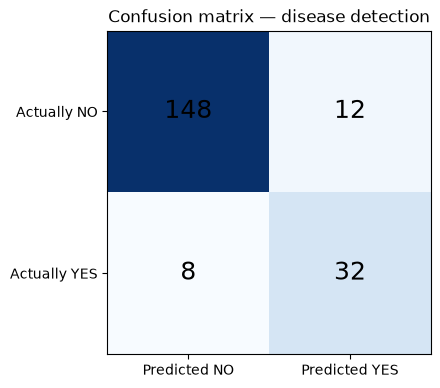

In [5]:
# --- Visualise the confusion matrix ---
fig, ax = plt.subplots(figsize=(5.5, 4.2))
ax.imshow(cm, cmap="Blues")
ax.set_xticks([0, 1]); ax.set_xticklabels(["Predicted NO", "Predicted YES"])
ax.set_yticks([0, 1]); ax.set_yticklabels(["Actually NO", "Actually YES"])
for i in range(2):
    for j in range(2):
        ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=18)
ax.set_title("Confusion matrix — disease detection")
plt.show()

📖 **What to read next — go deeper:** see **Section 3: The Confusion Matrix** in
`ML_Model_Evaluation.ipynb` — a deeper walk through TP/TN/FP/FN, more examples, and the
error-cost framing that drives the whole course.


<a id="sec3"></a>
## 3. Accuracy

### Definition

**Accuracy** answers: *how often is the model right overall?*

$$\text{Accuracy} = \frac{TP + TN}{TP + TN + FP + FN}$$

### Worked example (our 200 patients)

$$\text{Accuracy} = \frac{32 + 148}{200} = \frac{180}{200} = 0.90$$

The model is right 90% of the time. Sounds great… until we look closer.

### The trap: accuracy lies on imbalanced data

Suppose a dataset has **99% healthy** people and **1% sick**. A lazy model predicts
*"healthy"* for everyone. It is wrong about every sick person, yet:

$$\text{Accuracy} = \frac{0 + 198}{200} = 0.99$$

**99% accuracy — and it detected zero sick patients.** Is this model useful? For
disease detection: **absolutely not**. The same trap appears in fraud detection and
intrusion detection, where the interesting cases are rare.

> **Never judge an imbalanced problem by accuracy alone.**


In [6]:
# --- Why accuracy can be misleading ---
# 99% healthy, 1% sick. The "model" predicts healthy for everyone.
y_true_rare = np.array([1] * 10 + [0] * 990)
y_pred_all0 = np.zeros(1000, dtype=int)

acc = accuracy_score(y_true_rare, y_pred_all0)
rec = recall_score(y_true_rare, y_pred_all0)
print(f"Accuracy = {acc:.3f}   (looks great!)")
print(f"Recall   = {rec:.3f}   (found ZERO of the 10 sick people)")
print()
print("The model is useless for the problem, even though accuracy is 99%.")

Accuracy = 0.990   (looks great!)
Recall   = 0.000   (found ZERO of the 10 sick people)

The model is useless for the problem, even though accuracy is 99%.


📖 **What to read next — go deeper:** see **Section 4: Accuracy** in
`ML_Model_Evaluation.ipynb` — the accuracy trap in depth, more worked examples, and when
accuracy is — and is not — the metric you actually need.


<a id="sec4"></a>
## 4. Precision

### Definition

**Precision** answers: *of all the times the model said YES, how often was it right?*

$$\text{Precision} = \frac{TP}{TP + FP}$$

### Worked example (our 200 patients)

$$\text{Precision} = \frac{32}{32 + 12} = \frac{32}{44} \approx 0.727$$

Of 44 positive predictions, about 73% were correct; the other 27% were false alarms.

### When precision matters: false alarms are expensive

- **Spam filter:** FP = a real email lands in spam. Customers miss important mail.
- **Bank fraud alerts:** FP = a legitimate customer is blocked or interrogated. They get
  frustrated and take their business elsewhere.
- **Recommender systems:** FP = recommending something the user does not want. Cheap per
  event, but annoying at scale.

**High precision means fewer false alarms.** If FP costs you money or trust, precision
is the metric to watch.

### Python

```python
precision_score(y_true, y_pred)   # 0.727 in our example
```


In [7]:
# --- Precision: by hand and with scikit-learn ---
tp, fp, fn, tn = 32, 12, 8, 148
prec_hand = tp / (tp + fp)
prec_sk   = precision_score(y_true, y_pred)

print(f"By hand:       precision = {tp} / ({tp} + {fp}) = {prec_hand:.3f}")
print(f"scikit-learn:  precision = {prec_sk:.3f}")
print()
print("Meaning: when the model flags someone as sick, it is right about 73% of the time.")

By hand:       precision = 32 / (32 + 12) = 0.727
scikit-learn:  precision = 0.727

Meaning: when the model flags someone as sick, it is right about 73% of the time.


📖 **What to read next — go deeper:** see **Section 5: Precision** in
`ML_Model_Evaluation.ipynb` — more false-alarm business cases, additional worked
examples, and how precision behaves as the threshold changes.


<a id="sec5"></a>
## 5. Recall (Sensitivity)

### Definition

**Recall** answers: *of all the truly positive cases, how many did the model find?*

$$\text{Recall} = \frac{TP}{TP + FN}$$

### Worked example (our 200 patients)

$$\text{Recall} = \frac{32}{32 + 8} = \frac{32}{40} = 0.80$$

The model found 80% of the sick patients; it missed 20% of them.

### When recall matters: missed positives are expensive

- **Disease screening:** FN = a sick person is sent home untreated.
- **Security intrusion detection:** FN = an attack goes unnoticed.
- **Fraud detection:** FN = a fraudulent transaction is approved.

**High recall means few missed positives.** If missing a positive case is the dangerous
error, recall is the metric to watch.

### Python

```python
recall_score(y_true, y_pred)   # 0.80 in our example
```


In [8]:
# --- Recall: by hand and with scikit-learn ---
tp, fp, fn, tn = 32, 12, 8, 148
rec_hand = tp / (tp + fn)
rec_sk   = recall_score(y_true, y_pred)

print(f"By hand:       recall = {tp} / ({tp} + {fn}) = {rec_hand:.3f}")
print(f"scikit-learn:  recall = {rec_sk:.3f}")
print()
print("Meaning: the model catches 80% of the sick patients (and misses 20%).")

By hand:       recall = 32 / (32 + 8) = 0.800
scikit-learn:  recall = 0.800

Meaning: the model catches 80% of the sick patients (and misses 20%).


📖 **What to read next — go deeper:** see **Section 6: Recall / Sensitivity** in
`ML_Model_Evaluation.ipynb` — more missed-positive scenarios, the recall–specificity
relationship, and how recall is used in multi-class settings.


<a id="sec6"></a>
## 6. Specificity

### Definition

**Specificity** answers: *of all the truly negative cases, how many did the model
correctly identify?*

$$\text{Specificity} = \frac{TN}{TN + FP}$$

### Worked example (our 200 patients)

$$\text{Specificity} = \frac{148}{148 + 12} = \frac{148}{160} = 0.925$$

The model correctly cleared 92.5% of the healthy patients — only 7.5% got false alarms.

### Precision vs specificity — same idea, different question

| Metric | Question |
|---|---|
| **Precision** | Of the model's *YES* answers, how many are right? (denominator: TP + FP) |
| **Specificity** | Of the *true NO*s, how many did the model recognize? (denominator: TN + FP) |

Precision asks "can I trust a positive?"; specificity asks "how well do I avoid crying
wolf?" When false alarms are expensive (security alerts, spam), both matter — but
specificity looks at the negative class directly.


In [9]:
# --- Specificity: by hand ---
tp, fp, fn, tn = 32, 12, 8, 148
spec = tn / (tn + fp)

print(f"Specificity = {tn} / ({tn} + {fp}) = {spec:.3f}")
print("The model correctly clears 92.5% of healthy patients.")

Specificity = 148 / (148 + 12) = 0.925
The model correctly clears 92.5% of healthy patients.


📖 **What to read next — go deeper:** see **Section 7: Specificity** in
`ML_Model_Evaluation.ipynb` — how specificity and precision see the same errors from
different angles, with more examples and the trade-off discussion.


<a id="sec7"></a>
## 7. F1 Score

### Why another metric?

Precision and recall pull in opposite directions. A model that says YES too often gets
high recall but low precision; a cautious model gets high precision but low recall. The
**F1 score** combines both into one number — it is the **harmonic mean**:

$$\text{F1} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision} + \text{Recall}}$$

The harmonic mean is harsh when one number is small: F1 is only high when **both**
precision and recall are high.

### Examples

| Precision | Recall | F1 | Comment |
|---|---|---|---|
| 0.90 | 0.20 | 0.33 | High precision, terrible recall → low F1 |
| 0.50 | 0.60 | 0.55 | Both mediocre → mediocre F1 |
| 0.80 | 0.85 | 0.82 | Both high → high F1 |

### A warning

F1 treats precision and recall as equally important. If the real problem is much more
sensitive to one of them, the model with the highest F1 is **not** automatically the
best business solution. F1 is a convenient summary — not a substitute for thinking
about error costs.


In [10]:
# --- F1: by hand and with scikit-learn ---
prec, rec = 0.727, 0.800
f1_hand = 2 * prec * rec / (prec + rec)
f1_sk   = f1_score(y_true, y_pred)

print(f"By hand:       F1 = {f1_hand:.3f}")
print(f"scikit-learn:  F1 = {f1_sk:.3f}")
print()
print("Example of the warning: for disease screening, missing a patient (FN)")
print("is far worse than a false alarm, so recall matters more than precision —")
print("even if a different threshold gives a higher F1.")

By hand:       F1 = 0.762
scikit-learn:  F1 = 0.762

Example of the warning: for disease screening, missing a patient (FN)
is far worse than a false alarm, so recall matters more than precision —
even if a different threshold gives a higher F1.


📖 **What to read next — go deeper:** see **Section 8: F1 Score** in
`ML_Model_Evaluation.ipynb` — the harmonic mean explained, Fβ (weighted F1), and the
cases where F1 quietly misleads you.


<a id="sec8"></a>
## 8. The Precision–Recall Trade-off

### What is a threshold?

Most classifiers do not say "YES" or "NO" directly — they output a **probability**, e.g.
"60% chance this transaction is fraud". We then choose a **threshold**: predict fraud if
the probability is above it.

- **Low threshold** (e.g., 0.1): more things get flagged → **higher recall** (fewer
  misses) but **lower precision** (more false alarms).
- **High threshold** (e.g., 0.9): fewer things get flagged → **higher precision** (fewer
  false alarms) but **lower recall** (more misses).

The next cell shows this trade-off on a small fraud-like dataset.


In [11]:
# --- How the threshold trades precision against recall ---
X_f, y_f = make_classification(n_samples=1500, n_features=6, n_informative=5,
                               n_redundant=0, weights=[0.95, 0.05], random_state=42)
Xf_tr, Xf_te, yf_tr, yf_te = train_test_split(X_f, y_f, test_size=0.3,
                                              random_state=42, stratify=y_f)

model = LogisticRegression(max_iter=1000).fit(Xf_tr, yf_tr)
probs = model.predict_proba(Xf_te)[:, 1]

thresholds = [0.1, 0.3, 0.5, 0.7, 0.9]
print("threshold | precision | recall | flagged cases")
for t in thresholds:
    preds = (probs >= t).astype(int)
    p = precision_score(yf_te, preds)
    r = recall_score(yf_te, preds)
    print(f"   {t:.1f}    |   {p:.3f}   |  {r:.3f}  |  {(preds == 1).sum()}")

threshold | precision | recall | flagged cases
   0.1    |   0.391   |  0.720  |  46
   0.3    |   0.611   |  0.440  |  18
   0.5    |   0.692   |  0.360  |  13


   0.7    |   1.000   |  0.240  |  6
   0.9    |   1.000   |  0.160  |  4


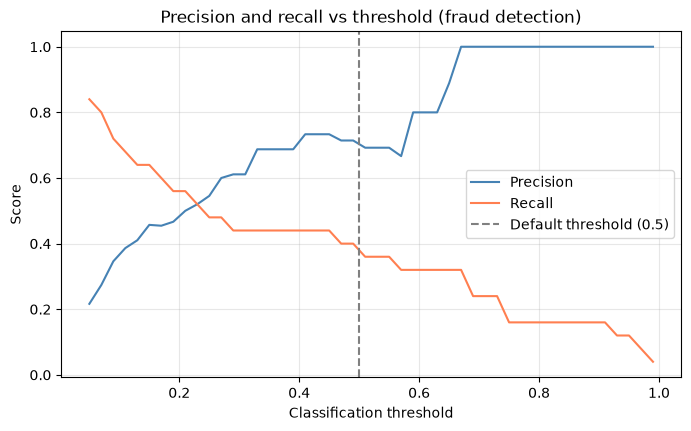

In [12]:
# --- Visualise the trade-off ---
grid = np.arange(0.05, 1.0, 0.02)
prec_grid, rec_grid = [], []
for t in grid:
    preds = (probs >= t).astype(int)
    prec_grid.append(precision_score(yf_te, preds))
    rec_grid.append(recall_score(yf_te, preds))

plt.figure(figsize=(8, 4.5))
plt.plot(grid, prec_grid, label="Precision", color="steelblue")
plt.plot(grid, rec_grid, label="Recall", color="coral")
plt.axvline(0.5, color="gray", linestyle="--", label="Default threshold (0.5)")
plt.xlabel("Classification threshold")
plt.ylabel("Score")
plt.title("Precision and recall vs threshold (fraud detection)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

**Read the plot from left to right:**

- Left (low threshold): recall is high, precision is low — we catch most fraud, but we
  also flag many innocent customers.
- Right (high threshold): precision is high, recall is low — few false alarms, but more
  fraud slips through.

**The business decision:** in fraud detection, a low threshold means more fraud caught
*but* more legitimate customers blocked or questioned. A high threshold means fewer
annoyed customers *but* more fraud approved. There is no universally "right" threshold —
it depends on which error costs more. **Choosing a threshold is a decision, not a
default.**


📖 **What to read next — go deeper:** see **Section 9: The Precision–Recall
Trade-off** in `ML_Model_Evaluation.ipynb` — threshold selection in depth, cost-based
threshold choice, and the precision–recall curve.


<a id="sec9"></a>
## 9. ROC Curve and AUC

### What the ROC curve shows

The **ROC curve** plots the trade-off between two rates as the threshold changes:

- **TPR (True Positive Rate)** = recall = TP / (TP + FN)
- **FPR (False Positive Rate)** = FP / (FP + TN) — the share of negatives wrongly
  flagged.

Every possible threshold is one point on the curve. The **diagonal** is what a random
guesser achieves. A good model arches above the diagonal.

### AUC

**AUC** is the area under the ROC curve — a single number summarizing the whole curve:

- **AUC = 1.0:** perfect separation.
- **AUC = 0.5:** no better than random guessing.
- **AUC < 0.5:** worse than random (something is wrong).

AUC answers: *if I pick a random positive and a random negative, how often does the
model give the positive the higher score?* It measures **ranking**, not accuracy.


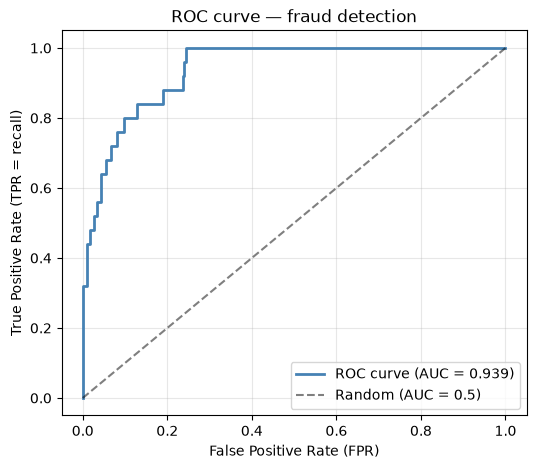

AUC = 0.939  -> the model ranks fraud above normal transactions
most of the time. AUC does NOT tell you which threshold to deploy.


In [13]:
# --- ROC curve and AUC on the fraud dataset ---
fpr, tpr, _ = roc_curve(yf_te, probs)
auc = roc_auc_score(yf_te, probs)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color="steelblue", lw=2, label=f"ROC curve (AUC = {auc:.3f})")
plt.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Random (AUC = 0.5)")
plt.xlabel("False Positive Rate (FPR)")
plt.ylabel("True Positive Rate (TPR = recall)")
plt.title("ROC curve — fraud detection")
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"AUC = {auc:.3f}  -> the model ranks fraud above normal transactions")
print("most of the time. AUC does NOT tell you which threshold to deploy.")

**A quick caveat:** on strongly imbalanced data (e.g., 1% fraud), ROC curves can look
optimistically good even when the model finds almost nothing — because the false
positive rate only counts the huge negative class. For rare events, a precision–recall
curve is often more informative. We meet this again in [Section 11](#sec11), and the
full notebook (`ML_Model_Evaluation.ipynb`) treats ROC vs precision–recall in depth.


📖 **What to read next — go deeper:** see **Sections 10–12: The ROC Curve · AUC ·
ROC-AUC vs Precision–Recall** in `ML_Model_Evaluation.ipynb` — the ROC curve in depth,
what AUC really measures, and why precision–recall beats ROC on imbalanced data.


<a id="sec10"></a>
## 10. The Classification Report

scikit-learn's `classification_report` prints precision, recall and F1 for **each
class**, plus averages. Let's look at it on the fraud model from [Section 8](#sec8).


In [14]:
# --- Classification report for the fraud model ---
from sklearn.metrics import classification_report

preds = (probs >= 0.5).astype(int)
print(classification_report(yf_te, preds, target_names=["Normal (0)", "Fraud (1)"]))

              precision    recall  f1-score   support

  Normal (0)       0.96      0.99      0.98       425
   Fraud (1)       0.69      0.36      0.47        25

    accuracy                           0.96       450
   macro avg       0.83      0.68      0.73       450
weighted avg       0.95      0.96      0.95       450



**How to read it:**

- Each row is one class. *Fraud (1)* is usually the interesting one.
- **precision / recall / f1-score:** same definitions as before, per class.
- **support:** how many real examples of that class were in the test set (used to trust
  the numbers — a row with support 5 is unreliable).
- **macro avg:** the plain average of the per-class scores — each class counts equally.
- **weighted avg:** the average weighted by support — big classes dominate.

**Do not read the report mechanically.** For fraud detection, the *Fraud* row is what
matters; the *Normal* row is almost perfect simply because normal transactions are easy.
The numbers only mean something in the context of the business question.


📖 **What to read next — go deeper:** see **Section 14: The Classification Report** in
`ML_Model_Evaluation.ipynb` — reading the report line by line, macro vs weighted
averages, and how the report fits into multiclass evaluation.


<a id="sec11"></a>
## 11. Imbalanced Datasets

**Class imbalance** means one class is much rarer than the other — 1% fraud, 1% sick,
0.5% intrusions. The interesting class is the rare one, and **accuracy is useless**
(remember [Section 3](#sec3)).

The next cell compares two models on a 99% / 1% dataset:


In [15]:
# --- Imbalanced data: the baseline that predicts "no" for everyone ---
X_i, y_i = make_classification(n_samples=2000, n_features=8, n_informative=4,
                               n_redundant=0, weights=[0.99, 0.01], random_state=5)
Xi_tr, Xi_te, yi_tr, yi_te = train_test_split(
    X_i, y_i, test_size=0.3, random_state=5, stratify=y_i)

# Baseline: never flag anything
base_pred = np.zeros(len(yi_te), dtype=int)

# A real model
lr = LogisticRegression(max_iter=1000).fit(Xi_tr, yi_tr)
lr_pred = lr.predict(Xi_te)

for name, p in [("Always says NO (baseline)", base_pred), ("Logistic regression", lr_pred)]:
    print(f"{name}:")
    print(f"  accuracy = {accuracy_score(yi_te, p):.3f}   "
          f"recall = {recall_score(yi_te, p):.3f}   "
          f"F1 = {f1_score(yi_te, p):.3f}")
print()
print("Both score ~99% accuracy. Only recall and F1 reveal which one finds fraud.")

Always says NO (baseline):
  accuracy = 0.987   recall = 0.000   F1 = 0.000
Logistic regression:
  accuracy = 0.985   recall = 0.125   F1 = 0.182

Both score ~99% accuracy. Only recall and F1 reveal which one finds fraud.


### Two models, which one is better?

| Model | Accuracy | Precision | Recall |
|---|---|---|---|
| **A** | 97% | 95% | 60% |
| **B** | 94% | 80% | 90% |

Model A has the higher accuracy. Model B finds far more of the rare cases.

**Which is better? There is no answer without the costs.**

- If the rare event is **fraud** and an FN is an approved fraud (expensive) → **Model B**
  — the higher recall is worth more than the accuracy difference.
- If the rare event is **a disease** and FP means invasive follow-up tests → maybe
  **Model A**, because precision (fewer false alarms) matters more.

The "best" model depends on the business problem, not on a leaderboard.


📖 **What to read next — go deeper:** see **Section 15: Imbalanced Datasets** in
`ML_Model_Evaluation.ipynb` — the full toolkit for rare events: resampling, class
weights, threshold tuning, and choosing between models for imbalance.


<a id="sec12"></a>
## 12. Cross-Validation

### Why one split is not enough

A single train/test split is one roll of the dice — the test set may happen to be easy
or hard by luck. **Cross-validation** repeats the experiment: the data is cut into
**K folds**, the model trains K times, and each fold is used for testing once. The
result is a mean **and** a spread.

**Stratified K-Fold** keeps the class proportions the same in every fold — important for
imbalanced data. We use the fraud dataset from [Section 8](#sec8) here.


In [16]:
# --- Cross-validation on the fraud dataset ---
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scores = cross_val_score(LogisticRegression(max_iter=1000), X_f, y_f,
                         cv=skf, scoring="f1")
print(f"F1 over 5 folds: {np.round(scores, 3)}")
print(f"mean = {scores.mean():.3f}  ±  {scores.std():.3f}")
print()
print("The folds swing from about 0.38 to 0.62: one lucky split could report")
print("either end. Report the mean AND the spread — a fragile model is a risk.")

F1 over 5 folds: [0.476 0.56  0.615 0.593 0.381]
mean = 0.525  ±  0.086

The folds swing from about 0.38 to 0.62: one lucky split could report
either end. Report the mean AND the spread — a fragile model is a risk.


📖 **What to read next — go deeper:** see **Section 17: Cross-Validation** in
`ML_Model_Evaluation.ipynb` — K-Fold and Stratified K-Fold in depth, common CV
mistakes, and the bias–variance trade-off of CV estimates.


<a id="sec13"></a>
## 13. Regression Metrics

Regression predicts **numbers** (house prices, temperatures), so errors are
*differences* between predictions and true values. Four standard metrics:

| Metric | Formula | What it answers |
|---|---|---|
| **MAE** | $$\frac{1}{n}\sum |y_i - \hat{y}_i|$$ | Average error in the original units. Easy to explain. |
| **MSE** | $$\frac{1}{n}\sum (y_i - \hat{y}_i)^2$$ | Average **squared** error — punishes big mistakes. Units are squared. |
| **RMSE** | $$\sqrt{MSE}$$ | Like MSE, but back in original units. |
| **R²** | $$1 - \frac{\sum (y_i - \hat{y}_i)^2}{\sum (y_i - \bar{y})^2}$$ | Fraction of variance explained. 1 = perfect, 0 = no better than predicting the mean. |

**Business meaning:** if MAE = 50,000 for house prices, the average prediction is off
by about 50,000 currency units. Whether that is acceptable depends on the application —
50,000 is small for a luxury house and huge for a used car.


In [17]:
# --- Regression metrics on a small house-price example ---
X_h, y_h = make_regression(n_samples=300, n_features=4, noise=30, random_state=7)
y_h = y_h + 200000   # shift to look like prices

Xh_tr, Xh_te, yh_tr, yh_te = train_test_split(X_h, y_h, test_size=0.3, random_state=7)
reg = LinearRegression().fit(Xh_tr, yh_tr)
pred = reg.predict(Xh_te)

mae = mean_absolute_error(yh_te, pred)
mse = mean_squared_error(yh_te, pred)
rmse = np.sqrt(mse)
r2 = r2_score(yh_te, pred)

print(f"MAE  = {mae:,.0f}   (average error, in currency)")
print(f"MSE  = {mse:,.0f}")
print(f"RMSE = {rmse:,.0f}")
print(f"R²   = {r2:.3f}   (fraction of price variance explained)")
print()
print(f"On average, the prediction is off by about {mae:,.0f} units.")

MAE  = 25   (average error, in currency)
MSE  = 933
RMSE = 31
R²   = 0.829   (fraction of price variance explained)

On average, the prediction is off by about 25 units.


📖 **What to read next — go deeper:** see **Section 20: Regression Metrics** in
`ML_Model_Evaluation.ipynb` — MAE / MSE / RMSE / R² in depth, plus MAPE, and how to
choose among regression metrics for your problem.


<a id="sec14"></a>
## 14. Mini Case Study: Loan Default Prediction

Let's put everything together on a realistic problem. A bank must decide whether to
**approve** or **reject** a loan. The model predicts the probability that the applicant
**will default** — that is the "positive" class.

### The business problem and the cost of errors

| Error | What it means | Business consequence |
|---|---|---|
| **FN** | Model says "no default" but the applicant defaults → loan approved | The bank **loses the loaned money**. Expensive per incident. |
| **FP** | Model says "will default" but the applicant would have repaid → loan rejected | The bank loses the **interest profit** and the customer may go elsewhere. Cheaper per incident. |

For this exercise we assume a default costs **10×** more than rejecting a good
customer: **FN = 10,000**, **FP = 1,000** currency units. (In a real project these
numbers would come from the bank's own financial analysis — and changing them changes
the answer, which is exactly the point.)


In [18]:
# --- Step 1: generate a small synthetic loan dataset ---
rng = np.random.RandomState(2024)
n = 1200

income           = rng.normal(60000, 25000, n).clip(15000, 250000)
credit_score     = rng.normal(680, 60, n).clip(400, 850)
debt_to_income   = rng.uniform(0.05, 0.75, n)
loan_amount      = rng.uniform(5000, 60000, n)
employment_years = rng.uniform(0, 20, n).round(1)

# Default probability: higher with debt and loan size, lower with credit score, etc.
logit = (-3.4 - 2.0 * (credit_score - 680) / 60
         + 2.0 * (debt_to_income - 0.4) / 0.2
         + 1.0 * (loan_amount - 32500) / 16000
         - 0.75 * (income - 60000) / 24000
         - 0.5 * (employment_years - 10) / 5)
p_default = 1 / (1 + np.exp(-logit))
default = (rng.rand(n) < p_default).astype(int)

df = pd.DataFrame({"income": income.round(0), "credit_score": credit_score.round(0),
                   "debt_to_income": debt_to_income.round(3),
                   "loan_amount": loan_amount.round(0),
                   "employment_years": employment_years, "default": default})
print("Class distribution:")
print(df["default"].value_counts(normalize=True).round(3))
print(f"Default rate: {df['default'].mean():.1%}")

# --- Step 2: train a model and evaluate at the default threshold 0.5 ---
features = ["income", "credit_score", "debt_to_income", "loan_amount", "employment_years"]
X = df[features]
y = df["default"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y)

model = LogisticRegression(max_iter=1000).fit(X_train, y_train)
probs = model.predict_proba(X_test)[:, 1]
preds = (probs >= 0.5).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, preds).ravel()
print()
print("Confusion matrix at threshold 0.5:")
print(f"  TN={tn}  FP={fp}")
print(f"  FN={fn}  TP={tp}")
print(f"  accuracy={accuracy_score(y_test, preds):.3f}  "
      f"precision={precision_score(y_test, preds):.3f}  "
      f"recall={recall_score(y_test, preds):.3f}")

Class distribution:
default
0    0.828
1    0.172
Name: proportion, dtype: float64
Default rate: 17.2%

Confusion matrix at threshold 0.5:
  TN=287  FP=11
  FN=25  TP=37
  accuracy=0.900  precision=0.771  recall=0.597


In [19]:
# --- Step 3: which threshold should the bank actually use? ---
COST_FP = 1000    # rejected good customer (lost profit)
COST_FN = 10000   # approved loan that defaults (lost money)

def total_cost(y_true, probs, t):
    preds = (probs >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, preds).ravel()
    return fp * COST_FP + fn * COST_FN, fp, fn

thresholds = [0.05, 0.10, 0.15, 0.30, 0.50, 0.70, 0.90]
print("threshold | FP | FN | total cost")
best = (float("inf"), None)
for t in thresholds:
    cost, fp, fn = total_cost(y_test, probs, t)
    print(f"   {t:.2f}    | {fp:3d} | {fn:3d} | {cost:9,.0f}")
    if cost < best[0]:
        best = (cost, t)

print()
print(f"Cheapest threshold in this sweep: {best[1]:.2f}  (total cost {best[0]:,.0f})")
print("Compare with the default 0.5 in the table above. The difference")
print("is the price of following a convention instead of the business costs.")

threshold | FP | FN | total cost
   0.05    | 119 |   3 |   149,000
   0.10    |  81 |   5 |   131,000
   0.15    |  60 |   9 |   150,000
   0.30    |  27 |  17 |   197,000
   0.50    |  11 |  25 |   261,000
   0.70    |   1 |  41 |   411,000
   0.90    |   0 |  57 |   570,000

Cheapest threshold in this sweep: 0.10  (total cost 131,000)
Compare with the default 0.5 in the table above. The difference
is the price of following a convention instead of the business costs.


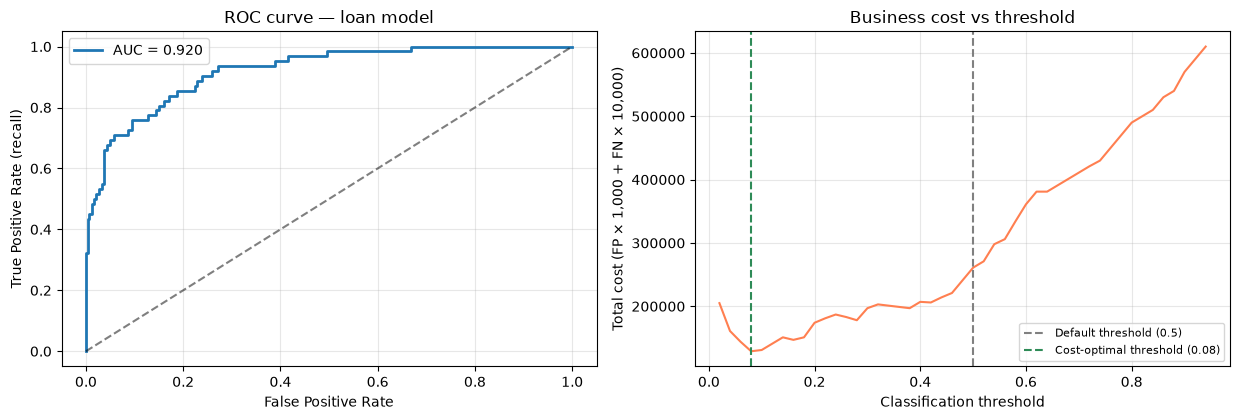

Cost at default 0.5: 261,000
Cost at optimal    : 129,000  (threshold 0.08)


In [20]:
# --- Step 4: ROC curve and the cost curve ---
fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.3))

fpr, tpr, _ = roc_curve(y_test, probs)
axes[0].plot(fpr, tpr, lw=2, label=f"AUC = {roc_auc_score(y_test, probs):.3f}")
axes[0].plot([0, 1], [0, 1], "k--", alpha=0.5)
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate (recall)")
axes[0].set_title("ROC curve — loan model")
axes[0].legend()
axes[0].grid(alpha=0.3)

ts = np.arange(0.02, 0.95, 0.02)
costs = [total_cost(y_test, probs, t)[0] for t in ts]
best_t = ts[int(np.argmin(costs))]
axes[1].plot(ts, costs, color="coral")
axes[1].axvline(0.5, color="gray", linestyle="--", label="Default threshold (0.5)")
axes[1].axvline(best_t, color="seagreen", linestyle="--",
                label=f"Cost-optimal threshold ({best_t:.2f})")
axes[1].set_xlabel("Classification threshold")
axes[1].set_ylabel("Total cost (FP × 1,000 + FN × 10,000)")
axes[1].set_title("Business cost vs threshold")
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()
print(f"Cost at default 0.5: {total_cost(y_test, probs, 0.5)[0]:,.0f}")
print(f"Cost at optimal    : {total_cost(y_test, probs, best_t)[0]:,.0f}  (threshold {best_t:.2f})")

### What did we learn?

- The model is good (AUC ≈ 0.92), but **AUC does not pick a threshold**.
- The default threshold **0.5 is just a convention**. On this problem the bank saves a
  large amount of money by lowering the threshold — rejecting more borderline
  applicants — because an approved default (FN) is so much more expensive than a
  rejected good customer (FP).
- The metric to report is the one that matches the question: here the business cares
  about the **cost of FN vs FP**, so we evaluated the cost, not just accuracy or F1.

**The takeaway of the whole notebook:** a model is only as useful as the decisions it
enables. Understand the problem → know what each error costs → pick the metric → pick
the threshold. The full `ML_Model_Evaluation.ipynb` shows a much longer version of this
case study, with three models, a full threshold analysis and an interactive explorer.


📖 **What to read next — go deeper:** see **Sections 21–23: Loan Default Case Study ·
Business Decisions · Cost-Sensitive Evaluation** in `ML_Model_Evaluation.ipynb` — the
full case study with three models, a complete threshold analysis, and the cost-matrix
decision rule.


<a id="sec15"></a>
## 15. Cheat Sheet

| Metric | Formula | Measures | Best used when | Business question |
|---|---|---|---|---|
| **Accuracy** | (TP+TN)/(all) | Overall correctness | Balanced classes | How often is the model right overall? |
| **Precision** | TP/(TP+FP) | Trust in positive predictions | False alarms are expensive | When the model says YES, how often should I believe it? |
| **Recall** | TP/(TP+FN) | Finding the positives | Missed positives are expensive | How many real positives can I find? |
| **Specificity** | TN/(TN+FP) | Correctly clearing negatives | Avoiding false alarms matters | How well do I avoid crying wolf? |
| **F1** | 2PR/(P+R) | Balance of precision & recall | One summary number needed | Can I balance precision and recall? |
| **ROC-AUC** | Area under ROC | Ranking quality across thresholds | Comparing models overall | How well does the model rank positives above negatives? |
| **MAE** | mean(|y−ŷ|) | Average error (regression) | Errors in original units | How far off is the average prediction? |
| **RMSE** | sqrt(MSE) | Error, penalizing big mistakes | Big errors are worse | How badly do big mistakes hurt? |
| **R²** | 1 − SS_res/SS_tot | Variance explained | Model comparison | How much of the variation does the model explain? |

**Rule of thumb:** start from the business problem, not from the metric list.


📖 **What to read next — go deeper:** see **Section 27: Final Cheat Sheet** in
`ML_Model_Evaluation.ipynb` — the complete one-page summary of every metric, formula,
and business question covered in the course.


<a id="sec16"></a>
## 16. Practice Exercises

Try these before looking at the solutions below.

### Beginner

1. A model gives TN = 85, FP = 15, FN = 25, TP = 75. Write the confusion matrix and
   compute accuracy by hand.
2. From the same matrix, compute precision and explain in one sentence what it means.
3. Compute recall and specificity from the same matrix.

### Intermediate

4. A rare-disease dataset has 1% sick people. A model predicts "healthy" for everyone.
   Its accuracy is 99%. Why is it useless? Which metric reveals this?
5. Model A: precision 0.9, recall 0.2. Model B: precision 0.5, recall 0.6. Compute F1
   for both. Which has the higher F1? Does that make it the better model?
6. A logistic regression flags 40 cases at threshold 0.5 and 12 cases at 0.7. Without
   seeing the data, what happened to precision, recall, FP and FN?

### Expert

7. A bank must decide between two models. FN (approved default) costs 10× an FP
   (rejected good customer). Model A: recall 0.55. Model B: recall 0.88 but precision
   0.60. Which would you choose and why? What information is still missing?
8. On a dataset with 0.5% fraud, a model reports AUC = 0.95 but precision = 0.03 at
   the threshold it uses. Explain how both can be true, and which number you would
   trust for the deployment decision.
9. Design the evaluation plan for a spam filter where a real email in the spam folder
   costs much more than spam in the inbox. Which metric should be maximized, and what
   does that imply about the threshold?


<a id="exercise-solutions"></a>
## Exercise Solutions

1. Confusion matrix (rows = truth, cols = prediction): [[85, 15], [25, 75]].
   Accuracy = (75 + 85) / 200 = 0.80.
2. Precision = 75 / (75 + 15) = 0.833. *Of all predicted positives, 83% were correct.*
3. Recall = 75 / (75 + 25) = 0.75. Specificity = 85 / (85 + 15) = 0.85.
4. Recall = 0 — it finds none of the sick people. Accuracy hides this on imbalanced
   data; recall (and F1, precision) reveal it.
5. F1(A) = 2·0.9·0.2/1.1 ≈ 0.33. F1(B) = 2·0.5·0.6/1.1 ≈ 0.55. B has the higher F1 —
   but if precision is what the problem needs, A may still be the better choice.
6. Raising the threshold means fewer positives: FP falls, recall falls, precision
   usually rises, FN rises. Whether total cost improves depends on the error costs.
7. Likely B if FN is 10× more expensive: catching more defaults saves more than the
   extra false alarms cost — but the missing information is the *exact* FP/FN counts
   and the actual costs, so the decision should be made with numbers, not intuition.
8. AUC measures ranking across all thresholds; precision is measured at one threshold.
   At 0.5 the model may flag many cases (high recall, low precision). AUC 0.95 can hide
   that precision at the operating point is 0.03 — for deployment, precision/recall at
   the chosen threshold matters.
9. Maximize precision (fewer real emails wrongly filtered) — or equivalently choose a
   high threshold. Since FP (real mail lost) is the expensive error, a cautious
   classifier is right for the business.

[⬆ Back to Table of Contents](#toc)


📖 **What to read next — go deeper:** see **Section 28: Practice Exercises** in
`ML_Model_Evaluation.ipynb` — 15 graded exercises with full solutions covering every
topic in the course.


<a id="sec17"></a>
## 17. Final Quiz

### Section A — Multiple choice

1. Accuracy is misleading when…
   a) classes are balanced
   b) the dataset is imbalanced
   c) the model is linear
   d) precision is high

2. Precision answers…
   a) how many positives did the model find?
   b) of all predicted positives, how many were correct?
   c) of all true negatives, how many were identified?
   d) how often is the model right overall?

3. Recall = …
   a) TP / (TP + FP)
   b) TP / (TP + FN)
   c) TN / (TN + FP)
   d) TN / (TN + FN)

4. Lowering the classification threshold usually…
   a) raises precision and lowers recall
   b) raises recall and lowers precision
   c) leaves both unchanged
   d) always lowers accuracy

5. AUC = 0.5 means…
   a) the model is perfect
   b) the model ranks no better than random
   c) accuracy is 50%
   d) the model is overfitting

### Section B — True / False

6. A 99% accurate model can still be useless for fraud detection.
7. The threshold 0.5 is always the best choice.
8. The model with the highest F1 is always the best business solution.
9. High recall means few false negatives.
10. MAE is measured in the same units as the target variable.

### Section C — Short answer

11. Give one example where precision matters more than recall.
12. Give one example where recall matters more than precision.
13. Why can a 99% accurate classifier still be useless?
14. In a confusion matrix, what is a false positive, in plain words?
15. Which error is more expensive in disease screening: FP or FN? Why?


📖 **What to read next — go deeper:** see **Section 29: Final Quiz** in
`ML_Model_Evaluation.ipynb` — a 25-question quiz with answers, plus the final
workflow that ties the whole course together.


<a id="quiz-answers"></a>
## Quiz Answers

1. **b** — accuracy is misleading when the dataset is imbalanced.
2. **b** — precision asks: of all predicted positives, how many were correct?
3. **b** — recall = TP / (TP + FN).
4. **b** — lowering the threshold flags more things: recall rises, precision falls.
5. **b** — AUC = 0.5 is no better than random ranking.
6. **True** — it may catch zero of the rare cases (see Section 3).
7. **False** — the right threshold follows the costs of FP and FN (Section 8 and 14).
8. **False** — F1 balances P and R, but the business may value one far more (Section 7).
9. **True** — recall = TP/(TP+FN); high recall means few missed positives.
10. **True** — MAE is an average of |y − ŷ|, in the target's units (Section 13).
11. Spam filtering (a real email lost is expensive); fraud alerts when false alarms
    annoy customers; medical tests with expensive or invasive follow-ups.
12. Disease screening (a missed patient is dangerous); security intrusion detection;
    fraud detection when approved fraud is very costly.
13. On imbalanced data a model can score 99% by predicting the majority class for
    everyone — while finding none of the rare, important cases.
14. The model said YES but the truth was NO — a false alarm.
15. Usually FN — a sick patient who is told they are healthy may not get treated. (The
    answer depends on context, which is exactly why costs must be discussed.)

[⬆ Back to Table of Contents](#toc)


## Final Message

You now know how to evaluate a machine learning model properly:

1. **Understand the problem** — what are we predicting, and what does each error cost?
2. **Look at the confusion matrix** — the four numbers tell the real story.
3. **Pick the metric for the problem** — accuracy for balanced problems, precision
   when false alarms hurt, recall when misses hurt, F1 for a summary, AUC for ranking.
4. **Choose the threshold deliberately** — it is a business decision, not a default.

> **Model evaluation is not about finding the model with the highest score. It is about
> finding the model — and the decision threshold — that best fits the real problem.**

**Want to go deeper?** Open `ML_Model_Evaluation.ipynb` for the full course: every
topic here in depth, plus probability calibration, cost-sensitive decision rules, data
leakage, time-series evaluation, cross-validation, multiclass evaluation, and
interactive widgets.
